In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
assets = pd.read_csv("../data/raw/assets.csv")
maintenance = pd.read_csv("../data/raw/maintenance.csv")
failures = pd.read_csv("../data/raw/failures.csv")
trains = pd.read_csv("../data/raw/trains.csv")
freight = pd.read_csv("../data/raw/freight.csv")

In [4]:
print(assets.head())


  asset_id  section_id   department asset_type  installation_year  \
0   TRK001  NDL-MTJ-01  ENGINEERING      TRACK               2012   
1   TRK002  NDL-MTJ-02  ENGINEERING      TRACK               2020   
2   SIG001  MTJ-AGC-01          S&T     SIGNAL               2016   
3   SIG002  AGC-GWL-01          S&T     SIGNAL               2022   
4   OHE001  GWL-JHS-01     TRACTION        OHE               2014   

   criticality  condition_score  failure_count last_maintenance_date  
0           10               62              7            2026-05-12  
1            8               88              1            2026-07-10  
2            9               71              4            2026-06-15  
3            7               94              0            2026-08-01  
4            9               68              5            2026-05-20  


In [5]:
print("Assets shape:", assets.shape)
print("Maintenance shape:", maintenance.shape)
print("Failures shape:", failures.shape)
print("Trains shape:", trains.shape)
print("Freight shape:", freight.shape)

Assets shape: (6, 9)
Maintenance shape: (6, 14)
Failures shape: (7, 7)
Trains shape: (5, 7)
Freight shape: (6, 6)


In [6]:
print("===== ASSETS =====")
display(assets)

print("===== MAINTENANCE =====")
display(maintenance)

print("===== FAILURES =====")
display(failures)

print("===== TRAINS =====")
display(trains)

print("===== FREIGHT =====")
display(freight)


===== ASSETS =====


,asset_id,section_id,department,asset_type,installation_year,criticality,condition_score,failure_count,last_maintenance_date
0,TRK001,NDL-MTJ-01,ENGINEERING,TRACK,2012,10,62,7,2026-05-12
1,TRK002,NDL-MTJ-02,ENGINEERING,TRACK,2020,8,88,1,2026-07-10
2,SIG001,MTJ-AGC-01,S&T,SIGNAL,2016,9,71,4,2026-06-15
3,SIG002,AGC-GWL-01,S&T,SIGNAL,2022,7,94,0,2026-08-01
4,OHE001,GWL-JHS-01,TRACTION,OHE,2014,9,68,5,2026-05-20
5,OHE002,JHS-BINA-01,TRACTION,OHE,2019,8,91,1,2026-07-22


===== MAINTENANCE =====


,task_id,asset_id,section_id,department,maintenance_type,defect_type,severity,criticality,created_date,due_date,overdue_days,estimated_duration,required_manpower,status
0,TMS001,TRK001,NDL-MTJ-01,ENGINEERING,REPAIR,RAIL_CRACK,9,10,2026-08-20,2026-09-01,1,90,8,PENDING
1,TMS002,TRK002,NDL-MTJ-02,ENGINEERING,INSPECTION,TRACK_WEAR,4,8,2026-08-25,2026-09-10,0,60,5,PENDING
2,SMMS001,SIG001,MTJ-AGC-01,S&T,REPAIR,SIGNAL_DEGRADATION,8,9,2026-08-22,2026-09-04,0,45,3,PENDING
3,SMMS002,SIG002,AGC-GWL-01,S&T,INSPECTION,SIGNAL_CHECK,3,7,2026-08-28,2026-09-15,0,30,2,PENDING
4,TDMS001,OHE001,GWL-JHS-01,TRACTION,REPAIR,OHE_INSULATOR,7,9,2026-08-18,2026-09-03,0,60,5,PENDING
5,TDMS002,OHE002,JHS-BINA-01,TRACTION,INSPECTION,OHE_CHECK,3,8,2026-08-29,2026-09-20,0,45,4,PENDING


===== FAILURES =====


,failure_id,asset_id,failure_date,failure_type,severity,downtime_hours,repair_duration_hours
0,F001,TRK001,2026-01-12,RAIL_FAILURE,9,8,6
1,F002,TRK001,2026-03-20,TRACK_FAILURE,8,6,5
2,F003,TRK001,2026-06-02,RAIL_FAILURE,10,10,7
3,F004,SIG001,2026-02-15,SIGNAL_FAILURE,8,3,2
4,F005,SIG001,2026-05-10,SIGNAL_FAILURE,7,2,2
5,F006,OHE001,2026-02-22,OHE_FAILURE,8,5,4
6,F007,OHE001,2026-07-01,OHE_FAILURE,9,7,5


===== TRAINS =====


,movement_id,train_id,section_id,train_type,entry_time,exit_time,priority
0,M001,12952,NDL-MTJ-01,RAJDHANI,2026-09-03 01:10,2026-09-03 01:25,HIGH
1,M002,12002,NDL-MTJ-01,SHATABDI,2026-09-03 02:10,2026-09-03 02:25,HIGH
2,M003,12952,MTJ-AGC-01,RAJDHANI,2026-09-03 02:40,2026-09-03 02:55,HIGH
3,M004,12626,MTJ-AGC-01,EXPRESS,2026-09-03 03:20,2026-09-03 03:35,HIGH
4,M005,12137,AGC-GWL-01,EXPRESS,2026-09-03 01:50,2026-09-03 02:10,MEDIUM


===== FREIGHT =====


,forecast_id,section_id,date,hour,expected_freight_count,forecast_confidence
0,FR001,NDL-MTJ-01,2026-09-03,0,2,0.82
1,FR002,NDL-MTJ-01,2026-09-03,1,1,0.76
2,FR003,NDL-MTJ-01,2026-09-03,2,3,0.91
3,FR004,MTJ-AGC-01,2026-09-03,1,2,0.80
4,FR005,MTJ-AGC-01,2026-09-03,2,3,0.89
5,FR006,AGC-GWL-01,2026-09-03,1,1,0.72


In [7]:
print("===== ASSET INFO =====")
assets.info()

print("\n===== MAINTENANCE INFO =====")
maintenance.info()

print("\n===== FAILURE INFO =====")
failures.info()

print("\n===== TRAIN INFO =====")
trains.info()

print("\n===== FREIGHT INFO =====")
freight.info()


===== ASSET INFO =====
<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   asset_id               6 non-null      str  
 1   section_id             6 non-null      str  
 2   department             6 non-null      str  
 3   asset_type             6 non-null      str  
 4   installation_year      6 non-null      int64
 5   criticality            6 non-null      int64
 6   condition_score        6 non-null      int64
 7   failure_count          6 non-null      int64
 8   last_maintenance_date  6 non-null      str  
dtypes: int64(4), str(5)
memory usage: 564.0 bytes

===== MAINTENANCE INFO =====
<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   task_id             6 non-null      str  
 1   asset_id            6

In [8]:
print("===== ASSETS STATISTICS =====")
display(assets.describe())

print("===== MAINTENANCE STATISTICS =====")
display(maintenance.describe())

print("===== FAILURE STATISTICS =====")
display(failures.describe())

print("===== TRAIN STATISTICS =====")
display(trains.describe())

print("===== FREIGHT STATISTICS =====")
display(freight.describe())

===== ASSETS STATISTICS =====


,installation_year,criticality,condition_score,failure_count
count,6.000000,6.000000,6.000000,6.00000
mean,2017.166667,8.500000,79.000000,3.00000
std,3.816630,1.048809,13.594116,2.75681
min,2012.000000,7.000000,62.000000,0.00000
25%,2014.500000,8.000000,68.750000,1.00000
50%,2017.500000,8.500000,79.500000,2.50000
75%,2019.750000,9.000000,90.250000,4.75000
max,2022.000000,10.000000,94.000000,7.00000


===== MAINTENANCE STATISTICS =====


,severity,criticality,overdue_days,estimated_duration,required_manpower
count,6.000000,6.000000,6.000000,6.000000,6.000000
mean,5.666667,8.500000,0.166667,55.000000,4.500000
std,2.658320,1.048809,0.408248,20.493902,2.073644
min,3.000000,7.000000,0.000000,30.000000,2.000000
25%,3.250000,8.000000,0.000000,45.000000,3.250000
50%,5.500000,8.500000,0.000000,52.500000,4.500000
75%,7.750000,9.000000,0.000000,60.000000,5.000000
max,9.000000,10.000000,1.000000,90.000000,8.000000


===== FAILURE STATISTICS =====


,severity,downtime_hours,repair_duration_hours
count,7.000000,7.000000,7.000000
mean,8.428571,5.857143,4.428571
std,0.975900,2.794553,1.902379
min,7.000000,2.000000,2.000000
25%,8.000000,4.000000,3.000000
50%,8.000000,6.000000,5.000000
75%,9.000000,7.500000,5.500000
max,10.000000,10.000000,7.000000


===== TRAIN STATISTICS =====


,train_id
count,5.00000
mean,12533.80000
std,446.80667
min,12002.00000
25%,12137.00000
50%,12626.00000
75%,12952.00000
max,12952.00000


===== FREIGHT STATISTICS =====


,hour,expected_freight_count,forecast_confidence
count,6.000000,6.000000,6.000000
mean,1.166667,2.000000,0.816667
std,0.752773,0.894427,0.073394
min,0.000000,1.000000,0.720000
25%,1.000000,1.250000,0.770000
50%,1.000000,2.000000,0.810000
75%,1.750000,2.750000,0.872500
max,2.000000,3.000000,0.910000


In [9]:
print("===== MISSING VALUES =====")

print("\nAssets:")
display(assets.isnull().sum())

print("\nMaintenance:")
display(maintenance.isnull().sum())

print("\nFailures:")
display(failures.isnull().sum())

print("\nTrains:")
display(trains.isnull().sum())

print("\nFreight:")
display(freight.isnull().sum())

===== MISSING VALUES =====

Assets:


asset_id                 0
section_id               0
department               0
asset_type               0
installation_year        0
criticality              0
condition_score          0
failure_count            0
last_maintenance_date    0
dtype: int64


Maintenance:


task_id               0
asset_id              0
section_id            0
department            0
maintenance_type      0
defect_type           0
severity              0
criticality           0
created_date          0
due_date              0
overdue_days          0
estimated_duration    0
required_manpower     0
status                0
dtype: int64


Failures:


failure_id               0
asset_id                 0
failure_date             0
failure_type             0
severity                 0
downtime_hours           0
repair_duration_hours    0
dtype: int64


Trains:


movement_id    0
train_id       0
section_id     0
train_type     0
entry_time     0
exit_time      0
priority       0
dtype: int64


Freight:


forecast_id               0
section_id                0
date                      0
hour                      0
expected_freight_count    0
forecast_confidence       0
dtype: int64

In [10]:
print("===== ASSET CATEGORIES =====")
print("Departments:")
print(assets["department"].value_counts())

print("\nAsset Types:")
print(assets["asset_type"].value_counts())

print("\n===== MAINTENANCE CATEGORIES =====")
print("Maintenance Types:")
print(maintenance["maintenance_type"].value_counts())

print("\nDefect Types:")
print(maintenance["defect_type"].value_counts())

print("\nStatuses:")
print(maintenance["status"].value_counts())

print("\n===== FAILURE TYPES =====")
print(failures["failure_type"].value_counts())

print("\n===== TRAIN TYPES =====")
print(trains["train_type"].value_counts())

print("\nTrain Priorities:")
print(trains["priority"].value_counts())


===== ASSET CATEGORIES =====
Departments:
department
ENGINEERING    2
S&T            2
TRACTION       2
Name: count, dtype: int64

Asset Types:
asset_type
TRACK     2
SIGNAL    2
OHE       2
Name: count, dtype: int64

===== MAINTENANCE CATEGORIES =====
Maintenance Types:
maintenance_type
REPAIR        3
INSPECTION    3
Name: count, dtype: int64

Defect Types:
defect_type
RAIL_CRACK            1
TRACK_WEAR            1
SIGNAL_DEGRADATION    1
SIGNAL_CHECK          1
OHE_INSULATOR         1
OHE_CHECK             1
Name: count, dtype: int64

Statuses:
status
PENDING    6
Name: count, dtype: int64

===== FAILURE TYPES =====
failure_type
RAIL_FAILURE      2
SIGNAL_FAILURE    2
OHE_FAILURE       2
TRACK_FAILURE     1
Name: count, dtype: int64

===== TRAIN TYPES =====
train_type
RAJDHANI    2
EXPRESS     2
SHATABDI    1
Name: count, dtype: int64

Train Priorities:
priority
HIGH      4
MEDIUM    1
Name: count, dtype: int64


In [11]:
print("===== FAILURES PER ASSET =====")
failure_counts = failures.groupby("asset_id").size().sort_values(ascending=False)
display(failure_counts)

print("\n===== MAINTENANCE TASKS PER ASSET =====")
maintenance_counts = maintenance.groupby("asset_id").size().sort_values(ascending=False)
display(maintenance_counts)

print("\n===== AVERAGE FAILURE SEVERITY BY ASSET =====")
avg_failure_severity = failures.groupby("asset_id")["severity"].mean().sort_values(ascending=False)
display(avg_failure_severity)

print("\n===== AVERAGE DOWNTIME BY FAILURE TYPE =====")
avg_downtime = failures.groupby("failure_type")["downtime_hours"].mean()
display(avg_downtime)

===== FAILURES PER ASSET =====


asset_id
TRK001    3
OHE001    2
SIG001    2
dtype: int64


===== MAINTENANCE TASKS PER ASSET =====


asset_id
OHE001    1
OHE002    1
SIG001    1
SIG002    1
TRK001    1
TRK002    1
dtype: int64


===== AVERAGE FAILURE SEVERITY BY ASSET =====


asset_id
TRK001    9.0
OHE001    8.5
SIG001    7.5
Name: severity, dtype: float64


===== AVERAGE DOWNTIME BY FAILURE TYPE =====


failure_type
OHE_FAILURE       6.0
RAIL_FAILURE      9.0
SIGNAL_FAILURE    2.5
TRACK_FAILURE     6.0
Name: downtime_hours, dtype: float64

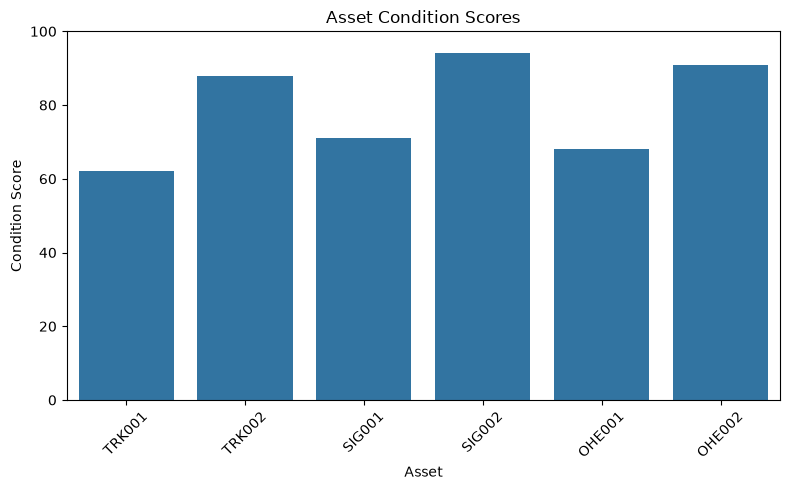

In [12]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=assets,
    x="asset_id",
    y="condition_score"
)

plt.title("Asset Condition Scores")
plt.xlabel("Asset")
plt.ylabel("Condition Score")
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

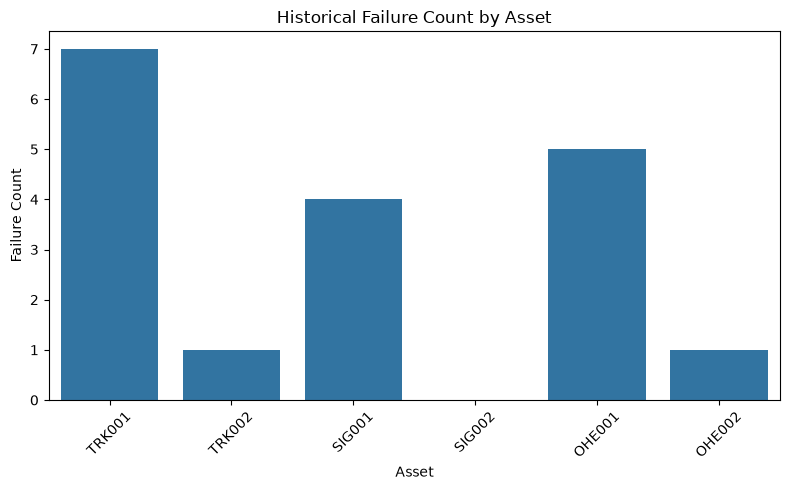

In [13]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=assets,
    x="asset_id",
    y="failure_count"
)

plt.title("Historical Failure Count by Asset")
plt.xlabel("Asset")
plt.ylabel("Failure Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

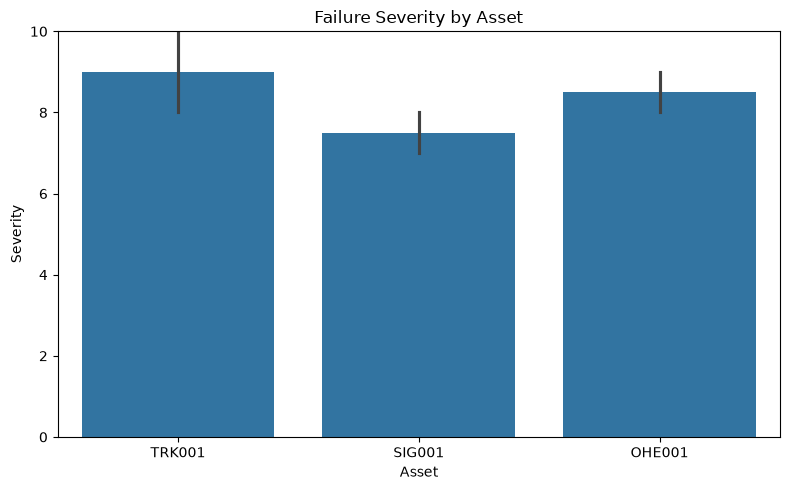

In [14]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=failures,
    x="asset_id",
    y="severity"
)

plt.title("Failure Severity by Asset")
plt.xlabel("Asset")
plt.ylabel("Severity")
plt.ylim(0, 10)
plt.tight_layout()
plt.show()

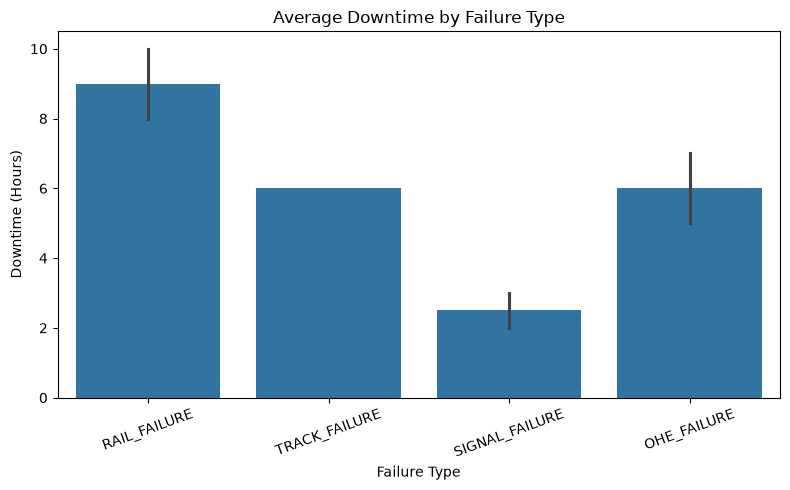

In [15]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=failures,
    x="failure_type",
    y="downtime_hours"
)

plt.title("Average Downtime by Failure Type")
plt.xlabel("Failure Type")
plt.ylabel("Downtime (Hours)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [16]:
# Correlation between important numerical asset features

numeric_columns = [
    "installation_year",
    "criticality",
    "condition_score",
    "failure_count"
]

correlation = assets[numeric_columns].corr()

display(correlation)

,installation_year,criticality,condition_score,failure_count
installation_year,1.000000,-0.974290,0.971403,-0.988431
criticality,-0.974290,1.000000,-0.953875,0.968400
condition_score,0.971403,-0.953875,1.000000,-0.987288
failure_count,-0.988431,0.968400,-0.987288,1.000000


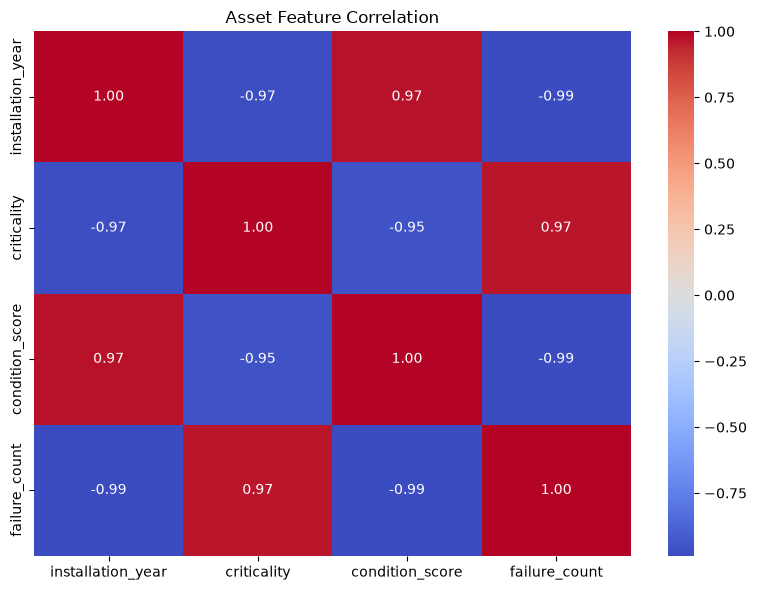

In [17]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Asset Feature Correlation")
plt.tight_layout()
plt.show()

In [18]:
print("Assets shape:", assets.shape)
print("Maintenance shape:", maintenance.shape)
print("Failures shape:", failures.shape)
print("Trains shape:", trains.shape)
print("Freight shape:", freight.shape)

Assets shape: (6, 9)
Maintenance shape: (6, 14)
Failures shape: (7, 7)
Trains shape: (5, 7)
Freight shape: (6, 6)


In [19]:
assets.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   asset_id               6 non-null      str  
 1   section_id             6 non-null      str  
 2   department             6 non-null      str  
 3   asset_type             6 non-null      str  
 4   installation_year      6 non-null      int64
 5   criticality            6 non-null      int64
 6   condition_score        6 non-null      int64
 7   failure_count          6 non-null      int64
 8   last_maintenance_date  6 non-null      str  
dtypes: int64(4), str(5)
memory usage: 564.0 bytes


In [20]:
assets["last_maintenance_date"] = pd.to_datetime(
    assets["last_maintenance_date"]
)

maintenance["created_date"] = pd.to_datetime(
    maintenance["created_date"]
)

maintenance["due_date"] = pd.to_datetime(
    maintenance["due_date"]
)

failures["failure_date"] = pd.to_datetime(
    failures["failure_date"]
)

trains["entry_time"] = pd.to_datetime(
    trains["entry_time"]
)

trains["exit_time"] = pd.to_datetime(
    trains["exit_time"]
)

freight["date"] = pd.to_datetime(
    freight["date"]
)

print("Date conversion complete.")

Date conversion complete.


In [21]:
current_year = 2026

assets["asset_age"] = (
    current_year - assets["installation_year"]
)

print(
    assets[
        ["asset_id", "installation_year", "asset_age"]
    ]
)

  asset_id  installation_year  asset_age
0   TRK001               2012         14
1   TRK002               2020          6
2   SIG001               2016         10
3   SIG002               2022          4
4   OHE001               2014         12
5   OHE002               2019          7


In [22]:
failure_counts = (
    failures
    .groupby("asset_id")
    .size()
    .reset_index(name="historical_failure_count")
)

assets = assets.merge(
    failure_counts,
    on="asset_id",
    how="left"
)

assets["historical_failure_count"] = (
    assets["historical_failure_count"]
    .fillna(0)
    .astype(int)
)

print(
    assets[
        ["asset_id", "failure_count", "historical_failure_count"]
    ]
)

  asset_id  failure_count  historical_failure_count
0   TRK001              7                         3
1   TRK002              1                         0
2   SIG001              4                         2
3   SIG002              0                         0
4   OHE001              5                         2
5   OHE002              1                         0


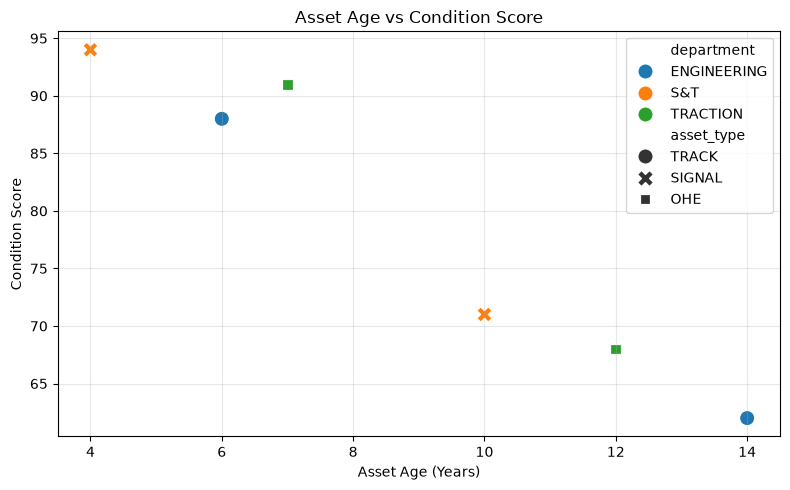

In [23]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=assets,
    x="asset_age",
    y="condition_score",
    hue="department",
    style="asset_type",
    s=120
)

plt.title("Asset Age vs Condition Score")
plt.xlabel("Asset Age (Years)")
plt.ylabel("Condition Score")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()